=== Überlebensrate nach Klasse ===
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

=== Überlebensrate nach Geschlecht ===
Sex
0    0.188908
1    0.742038
Name: Survived, dtype: float64


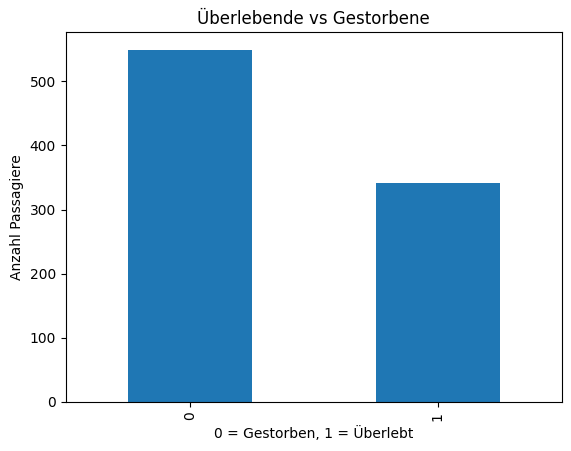


=== Cross Validation ===
Durchschnitt: 0.8092712321888144

=== Classification Report ===
              precision    recall  f1-score   support

   Gestorben       0.83      0.91      0.87       111
    Überlebt       0.83      0.71      0.76        68

    accuracy                           0.83       179
   macro avg       0.83      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179



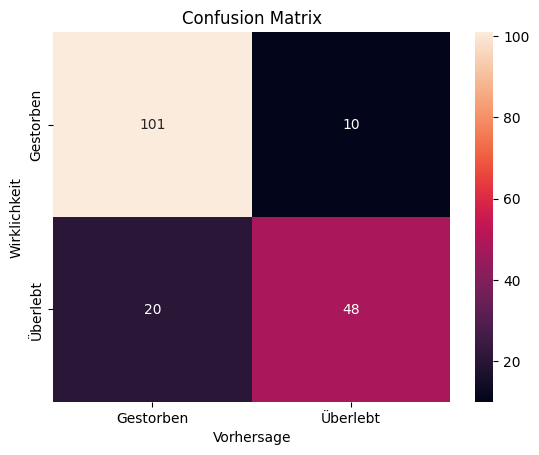

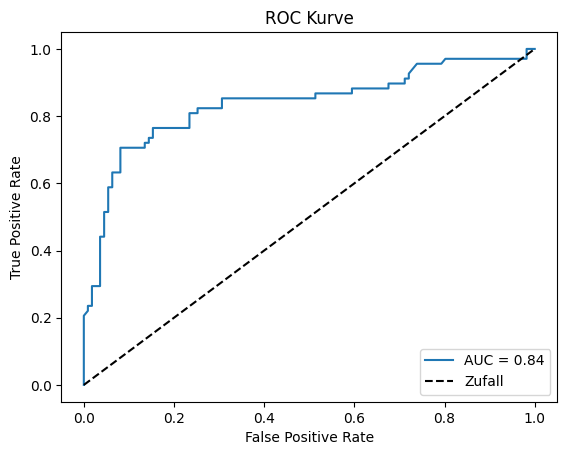

AUC Score: 0.8363804981452041


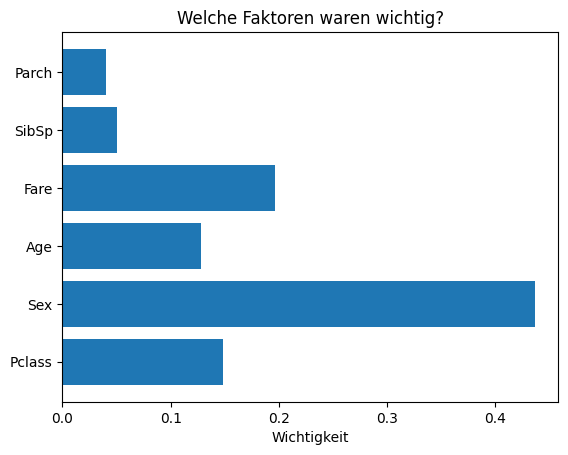


Modell gespeichert!
Vorhersage: Überlebt!


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
import seaborn as sns

# Daten laden
df = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")

# Data Cleaning
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

# Analyse
print("=== Überlebensrate nach Klasse ===")
print(df.groupby("Pclass")["Survived"].mean())
print("\n=== Überlebensrate nach Geschlecht ===")
print(df.groupby("Sex")["Survived"].mean())

# Visualisierung
df["Survived"].value_counts().plot(kind="bar")
plt.title("Überlebende vs Gestorbene")
plt.xlabel("0 = Gestorben, 1 = Überlebt")
plt.ylabel("Anzahl Passagiere")
plt.show()

# ML Vorbereitung
X = df[["Pclass", "Sex", "Age", "Fare", "SibSp", "Parch"]]
y = df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Modell trainieren
modell = RandomForestClassifier(n_estimators=100, max_depth=5)
modell.fit(X_train, y_train)

# Cross Validation
scores = cross_val_score(modell, X, y, cv=5)
print("\n=== Cross Validation ===")
print("Durchschnitt:", scores.mean())

# Modell Bewertung
y_pred = modell.predict(X_test)
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=["Gestorben", "Überlebt"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Gestorben", "Überlebt"],
            yticklabels=["Gestorben", "Überlebt"])
plt.title("Confusion Matrix")
plt.ylabel("Wirklichkeit")
plt.xlabel("Vorhersage")
plt.show()

# ROC Kurve
y_prob = modell.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], "k--", label="Zufall")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Kurve")
plt.legend(loc="lower right")
plt.show()
print("AUC Score:", auc_score)

# Feature Importance
feature_names = ["Pclass", "Sex", "Age", "Fare", "SibSp", "Parch"]
importance = modell.feature_importances_
plt.barh(feature_names, importance)
plt.title("Welche Faktoren waren wichtig?")
plt.xlabel("Wichtigkeit")
plt.show()

# Modell speichern
joblib.dump(modell, "titanic_modell.pkl")
print("\nModell gespeichert!")

# Vorhersage
neuer_passagier = pd.DataFrame([{
    "Pclass": 1,
    "Sex": 1,
    "Age": 25,
    "Fare": 100,
    "SibSp": 0,
    "Parch": 0
}])
vorhersage = modell.predict(neuer_passagier)
print("Vorhersage:", "Überlebt!" if vorhersage[0] == 1 else "Nicht überlebt!")